In [3]:
import pandas as pd
import glob
import os
import re
import sys
from omegaconf import OmegaConf

# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters
from src.analysis.sensitivity import SensitivityAnalyzer
from src.validity.validity_criteria import validate_polarization_curves
parameter_ranges = OmegaConf.load('../param_config.yaml')

In [4]:
model = pd.read_pickle('../sampling_test/xgb_nconfig_all_with_outerCV_final_model.pkl')

In [5]:
data = pd.read_pickle(r"../sampling_test/validated_final_df_57344_imputed.pkl")
data = data[data['classification'] == 'valid']
parameter_ranges = OmegaConf.load('../param_config.yaml')

In [6]:
criteria = {
    "start_in_range": True,
    "approx_monotonic": True,
    "low_ifc_positive_voltage": True
}

validated_df = validate_polarization_curves(
    data,
    apply_criteria=criteria,
    filter_invalid=True,
    voltage_range=(0, 1.23),
    approx_monotonic_threshold=0.05
)

print(len(validated_df))

54754


In [7]:
columns = list(parameter_ranges.keys())
columns.extend(['Ucell', 'ifc', 'SHA256'])

n_configs = 10000
sampled_df = validated_df.sample(n=n_configs, random_state=42).reset_index(drop=True)

# Explode both columns together
df_exploded = sampled_df[columns].explode(['ifc', 'Ucell'], ignore_index=True)

print("\nExploded DataFrame:")
print(len(df_exploded))
df_exploded.head()


Exploded DataFrame:
310000


,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Ucell,ifc,SHA256
0,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.971062,0.000813,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
1,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.927253,0.100812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
2,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.8958,0.200812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
3,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.87028,0.300812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...
4,343.804109,214920.650007,2.431343,0.48481,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.848665,0.400812,f1bb7220e0a9e4d7ec051d321cbc53c20910f205e6f7fb...


In [13]:
X = df_exploded[list(parameter_ranges.keys()) + ['ifc']]
y = df_exploded['Ucell']

In [12]:
X

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,ifc
0,343.804109,214920.650007,2.431343,0.484810,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.000813
1,343.804109,214920.650007,2.431343,0.484810,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.100812
2,343.804109,214920.650007,2.431343,0.484810,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.200812
3,343.804109,214920.650007,2.431343,0.484810,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.300812
4,343.804109,214920.650007,2.431343,0.484810,0.731942,3.325909,0.289988,0.198927,5,0.000003,40.551519,33.053013,0.177528,0.400812
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309995,347.206267,241211.762988,1.157302,0.429365,0.718745,2.271874,0.174011,0.203568,4,0.000005,17.916091,36.076418,2.046884,2.600824
309996,347.206267,241211.762988,1.157302,0.429365,0.718745,2.271874,0.174011,0.203568,4,0.000005,17.916091,36.076418,2.046884,2.700824
309997,347.206267,241211.762988,1.157302,0.429365,0.718745,2.271874,0.174011,0.203568,4,0.000005,17.916091,36.076418,2.046884,2.800824
309998,347.206267,241211.762988,1.157302,0.429365,0.718745,2.271874,0.174011,0.203568,4,0.000005,17.916091,36.076418,2.046884,2.900824


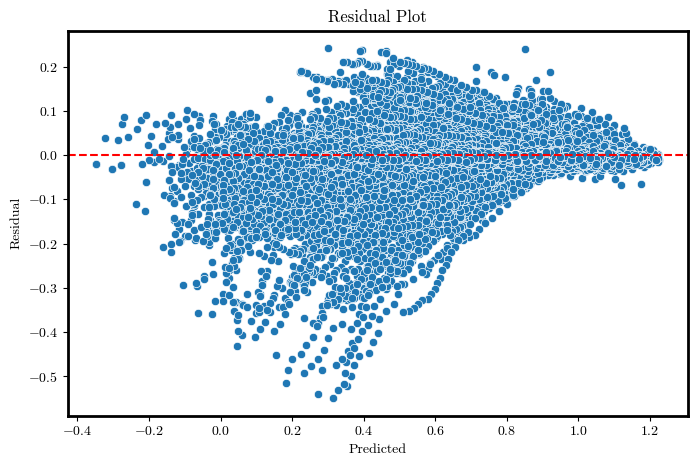

In [21]:
y_pred = model.predict(X)
residuals = y - y_pred

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()




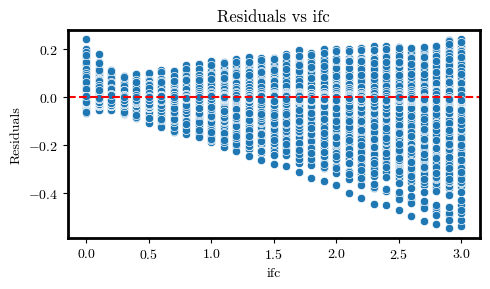

In [26]:
for col in X.columns:
    if col != 'ifc':
        continue
    plt.figure(figsize=(5, 3))
    sns.scatterplot(x=X[col], y=residuals)
    plt.axhline(0, color="red", linestyle="--")
    plt.title(f"Residuals vs {col}")
    plt.xlabel(col)
    plt.ylabel("Residuals")
    plt.tight_layout()
    plt.show()


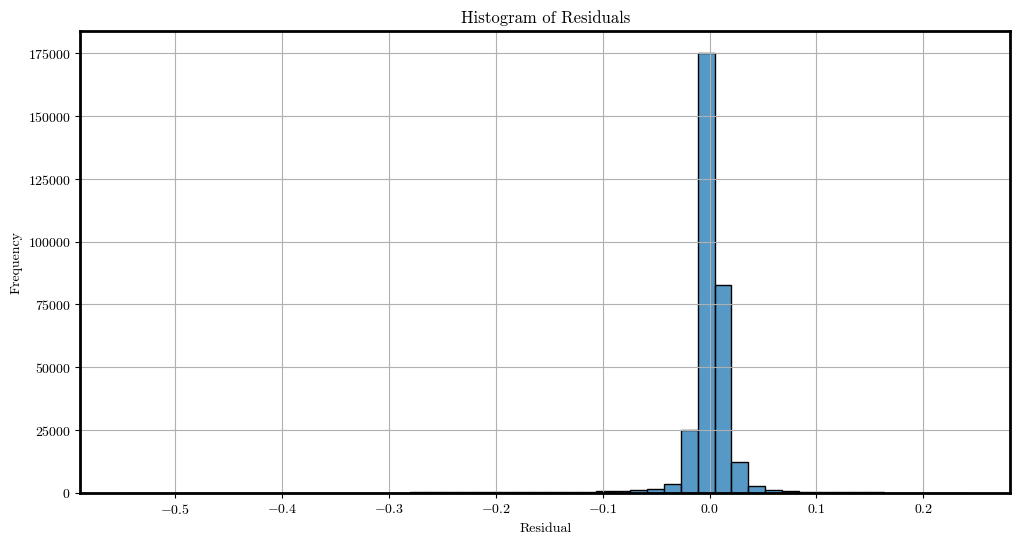

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))  # wider and taller
sns.histplot(residuals, bins=50)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.grid(True)
plt.show()


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

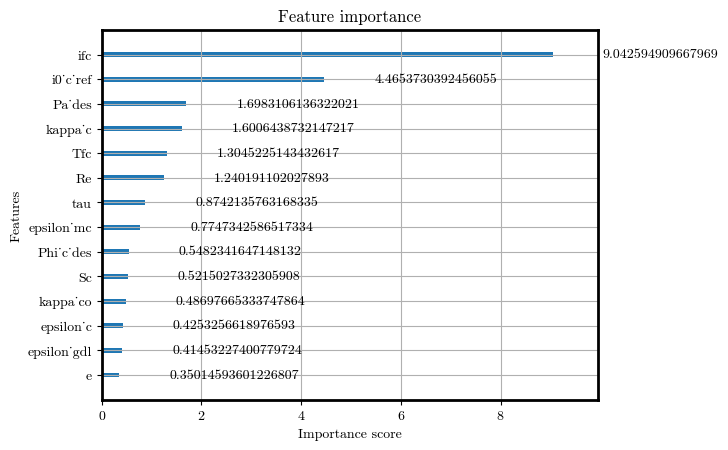

In [25]:
from xgboost import plot_importance
plot_importance(model, importance_type='gain')


In [27]:
from sklearn.model_selection import train_test_split

X_resid_train, X_resid_test, y_resid_train, y_resid_test = train_test_split(
    X, residuals, test_size=0.2, shuffle=False  # keep temporal order if applicable
)
from xgboost import XGBRegressor

model_resid = XGBRegressor()
model_resid.fit(X_resid_train, y_resid_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

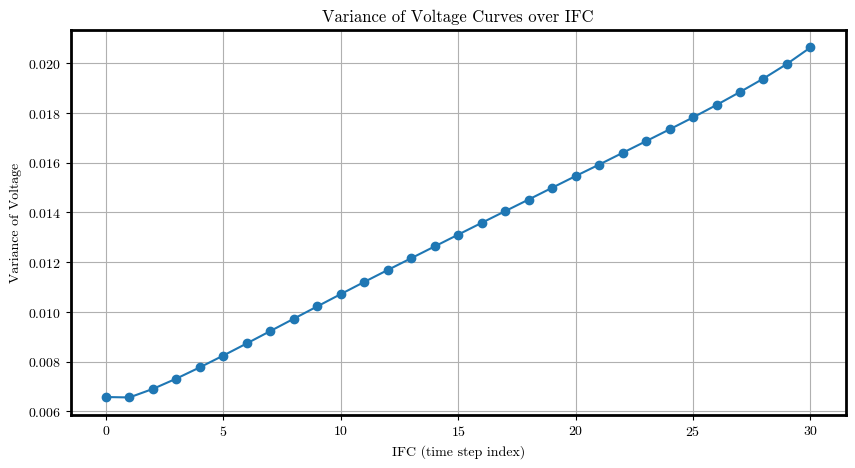

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Convert the list of voltage curves into a 2D numpy array
# Each row = one sample's voltage curve, each column = time step (IFC)
voltage_curves = np.array(validated_df['Ucell'].tolist())

# Calculate variance at each time point (along rows)
variance_per_ifc = np.var(voltage_curves, axis=0)

# Plot variance vs IFC index
plt.figure(figsize=(10, 5))
plt.plot(variance_per_ifc, marker='o')
plt.xlabel("IFC (time step index)")
plt.ylabel("Variance of Voltage")
plt.title("Variance of Voltage Curves over IFC")
plt.grid(True)
plt.show()


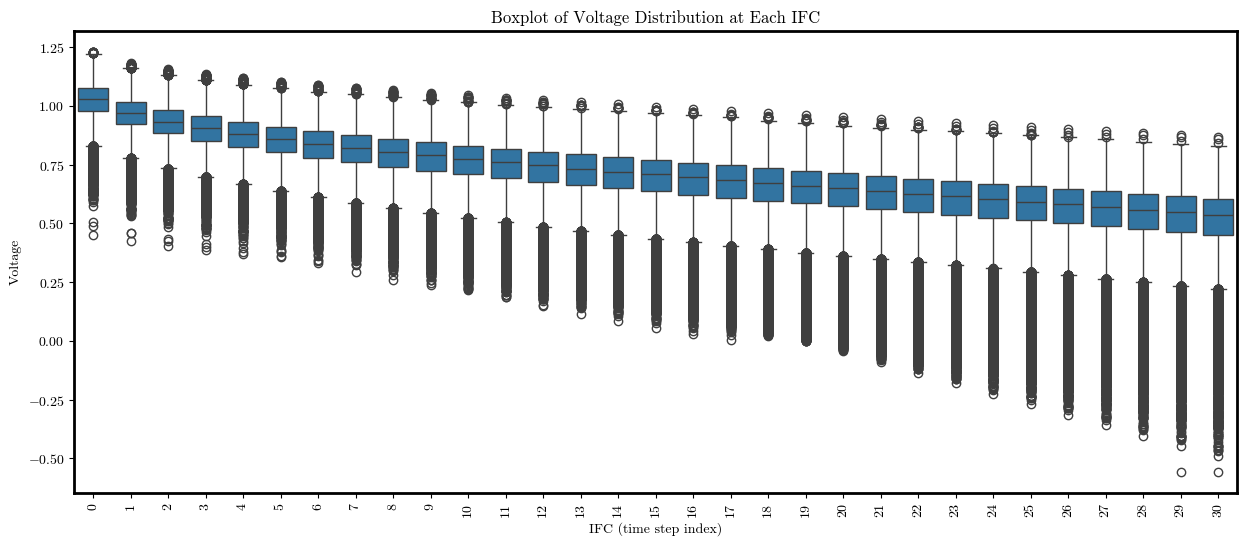

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert voltage curves into 2D array (samples × IFCs)
voltage_curves = np.array(validated_df['Ucell'].tolist())

# Convert to long-form DataFrame for easier plotting with seaborn
df_long = pd.DataFrame(voltage_curves).melt(var_name='IFC', value_name='Voltage')

plt.figure(figsize=(15, 6))
sns.boxplot(x='IFC', y='Voltage', data=df_long)

plt.xlabel("IFC (time step index)")
plt.ylabel("Voltage")
plt.title("Boxplot of Voltage Distribution at Each IFC")
plt.xticks(rotation=90)  # Rotate x labels if many points
plt.show()


In [66]:
idx = np.where(residuals < -0.2)[0]
unique_sha256 = df_exploded.iloc[idx]['SHA256'].unique()
filtered_df = data[data['SHA256'].isin(unique_sha256)]
filtered_df

,SHA256,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,...,Ucell_22,Ucell_23,Ucell_24,Ucell_25,Ucell_26,Ucell_27,Ucell_28,Ucell_29,Ucell_30,classification
15021,ece16caa80f2a915929d79f534d9b25b69655b1edece52...,341.415620,231603.430721,2.416012,0.240502,0.775912,3.771172,0.356557,0.216838,4,...,-0.117627,-0.156837,-0.195549,-0.233790,-0.271586,-0.308963,-0.345937,-0.382507,-0.418724,valid
15121,2a0150e9a12a650ee48ca4c265abc27336945534901abe...,341.710069,275013.257166,1.767655,0.414588,0.693782,3.326170,0.329286,0.248802,5,...,0.089179,0.058331,0.027777,-0.002398,-0.032291,-0.061965,-0.091445,-0.120749,-0.149893,valid
15435,1eb18d919590ea7c15c1efde98fb70cfbe54140c0c0d1d...,340.581634,204920.733198,2.963299,0.362406,0.585239,3.260842,0.376641,0.191221,5,...,0.384154,0.361864,0.339714,0.317695,0.295732,0.273788,0.251842,0.229868,0.207843,valid
15550,b03dda4f482b291ed45be258ed76e74621870693cce41a...,339.725939,176741.122990,2.510773,0.408478,0.742317,2.680389,0.248408,0.199804,5,...,-0.020150,-0.052262,-0.084058,-0.115522,-0.146650,-0.177474,-0.208007,-0.238260,-0.268248,valid
16218,4fb30272e74074a14c8a3c9b07585d13d5b3088c8a0222...,334.859649,145530.396866,2.041977,0.543236,0.763653,2.775612,0.269313,0.166100,3,...,-0.072853,-0.109087,-0.144751,-0.179882,-0.214513,-0.248676,-0.282399,-0.315710,-0.348633,valid
17227,4699fa0109f2563171c41c26d8abf4314881b890fdf734...,341.083426,165862.201976,1.819417,0.685193,0.681018,2.652000,0.253858,0.207752,3,...,-0.045144,-0.077521,-0.109425,-0.140886,-0.171933,-0.202596,-0.232899,-0.262868,-0.292527,valid
17946,8eb7b300b19b047f01f8a2794f37e10e97b81f2179f764...,342.858827,171439.399150,1.641969,0.298478,0.720329,2.863222,0.264496,0.296847,4,...,-0.100638,-0.135642,-0.170254,-0.204465,-0.238285,-0.271729,-0.304812,-0.337554,-0.369972,valid
18189,7c26cd23845df42384edbe12366769a2864ba894efed2f...,338.573467,213766.319681,1.169084,0.200107,0.784238,3.587016,0.344874,0.206085,5,...,-0.063396,-0.101493,-0.139145,-0.176452,-0.213447,-0.250158,-0.286606,-0.322816,-0.358808,valid
18190,b3b7d7650c92c164d88b49161bbfcf7509dc39087f86ef...,338.573467,213766.319681,1.169084,0.121439,0.743942,3.587016,0.344874,0.206085,5,...,-0.058637,-0.096901,-0.134693,-0.172150,-0.209329,-0.246261,-0.282972,-0.319485,-0.355825,valid
18879,664c50d0acb1562eee6af33f6ebde3fd401b37f0c6cac6...,348.160452,257789.062672,2.234258,0.131158,0.583516,3.372316,0.358204,0.177305,4,...,0.003754,-0.023820,-0.051796,-0.079911,-0.108038,-0.136139,-0.164201,-0.192228,-0.220232,valid


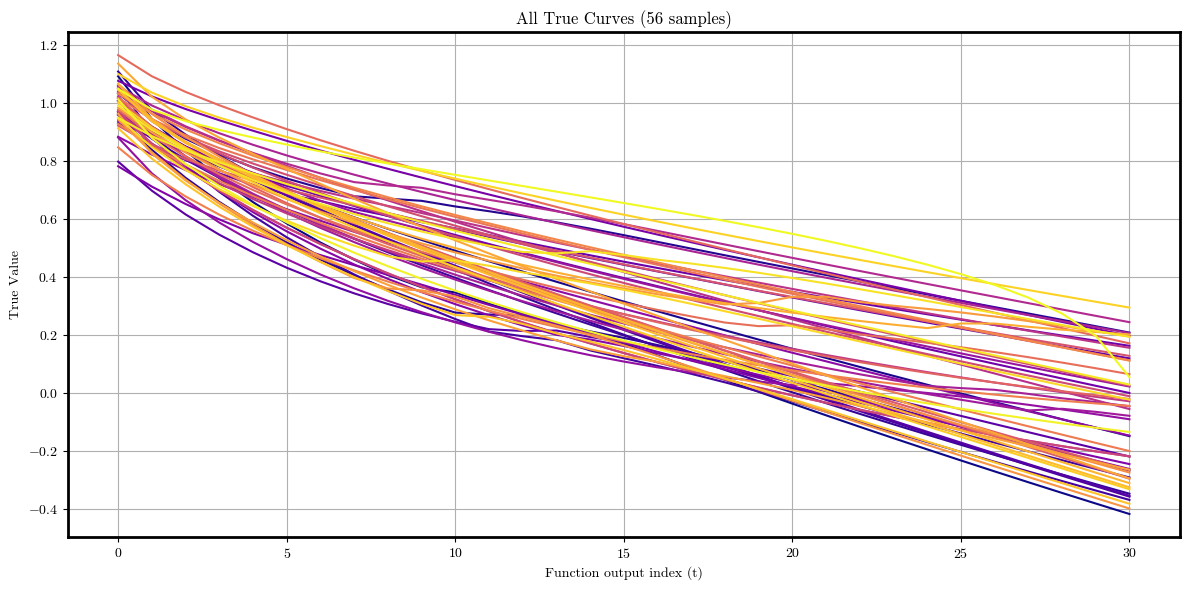

In [68]:
import matplotlib.pyplot as plt
import numpy as np

def plot_all_true_curves(Y_true):
    """
    Plot all true curves from Y_true.
    
    Args:
        Y_true (np.array): True function outputs, shape (n_samples_total, T)
    """
    n_samples = Y_true.shape[0]
    
    plt.figure(figsize=(12, 6))
    colors = plt.cm.plasma(np.linspace(0, 1, n_samples))
    
    for idx, color in zip(range(n_samples), colors):
        t = np.arange(Y_true.shape[1])
        plt.plot(t, Y_true[idx], label=f'Sample {idx}', color=color)
    
    plt.xlabel('Function output index (t)')
    plt.ylabel('True Value')
    plt.title(f'All True Curves ({n_samples} samples)')
    plt.grid(True)
 
    # Uncomment if you want legend:
    # plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

curves = np.array(filtered_df['Ucell'].tolist())
plot_all_true_curves(curves)
